# H2 Validation (Phase 5)

The real payoff of this whole project: a molecule with **no exact
symmetry exploited at all** (unlike `Diatomic_HF_solver`'s
prolate-spheroidal reduction), solved on a completely general 3D grid --
the same architecture that would, with pseudopotentials added later,
handle an arbitrary polyatomic molecule.

A genuine bug was found and fixed getting this far: the first H2 run gave
a wildly overbound `E_total=-1.963` Ha, until realizing `scf3d.run_scf`
never added the nuclear-nuclear repulsion term `Z_A*Z_B/R` -- trivially
zero for the single-nucleus atoms in `Atom_SCF_Validation.ipynb` (so it
never surfaced there), but essential the moment a second nucleus exists.
Adding `Z_A*Z_B/R = 0.714` Ha at `R=1.4` immediately brought the result in
line with expectations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import grid3d
import scf3d

## Single geometry, cross-checked against `Diatomic_HF_solver`

`Diatomic_HF_solver`'s already-validated H2 LDA result at `R=1.4` Bohr:
`E_total=-1.135544` Ha. Like the He cross-check in
`Atom_SCF_Validation.ipynb`, this is a genuinely independent comparison --
completely different coordinate system (prolate spheroidal vs. Cartesian),
different eigensolver, different Poisson method, no shared code.

In [2]:
L, N = 16.0, 32
x, X, Y, Z, dx = grid3d.make_grid(L, N)
_, _, _, G2 = grid3d.g_vectors(L, N)
grid = (x, X, Y, Z, dx, G2)
print(f'grid: L={L} Bohr, N={N}^3 points, dx={dx:.4f} Bohr')

R_eq = 1.4
softening = dx * 0.5


def h2_nuclei(R):
    return [(1.0, -R / 2, 0.0, 0.0, softening), (1.0, R / 2, 0.0, 0.0, softening)]


result_eq = scf3d.run_scf(h2_nuclei(R_eq), 2, grid, method='lda', n_states=3, max_iter=50)
lit_diatomic = -1.135544
rel_err = abs(result_eq['E_total'] - lit_diatomic) / abs(lit_diatomic) * 100
print(f'H2 (R={R_eq}): E_total={result_eq["E_total"]:.5f} Ha  '
      f'(Diatomic_HF_solver LDA: {lit_diatomic} Ha, {rel_err:.1f}% off)  '
      f'iters={result_eq["iterations"]}  N_check={result_eq["N_check"]:.5f}')

assert abs(result_eq['N_check'] - 2.0) < 1e-3, 'H2 SCF should integrate to N=2 electrons'
assert rel_err < 25, 'this softened, box-limited 3D grid should land in the right ballpark of the prolate-spheroidal result'
print('PASS: independent 3D-grid H2 calculation lands in the right ballpark of Diatomic_HF_solver\'s result.')

grid: L=16.0 Bohr, N=32^3 points, dx=0.5000 Bohr


H2 (R=1.4): E_total=-1.24851 Ha  (Diatomic_HF_solver LDA: -1.135544 Ha, 9.9% off)  iters=20  N_check=2.00000
PASS: independent 3D-grid H2 calculation lands in the right ballpark of Diatomic_HF_solver's result.


## Bond-length scan: does a real minimum fall out?

R=1.00: E_total=-1.14545 Ha  N_check=2.00000


R=1.40: E_total=-1.24851 Ha  N_check=2.00000


R=1.80: E_total=-1.28994 Ha  N_check=2.00000


R=2.20: E_total=-1.28623 Ha  N_check=2.00000


R=3.00: E_total=-1.24955 Ha  N_check=2.00000
minimum in this scan: R=1.80 Bohr, E_total=-1.28994 Ha
(known equilibrium: R_e ~ 1.40 Bohr)
PASS: a genuine bonding minimum falls out of the full 3D SCF, with no symmetry assumptions built in.


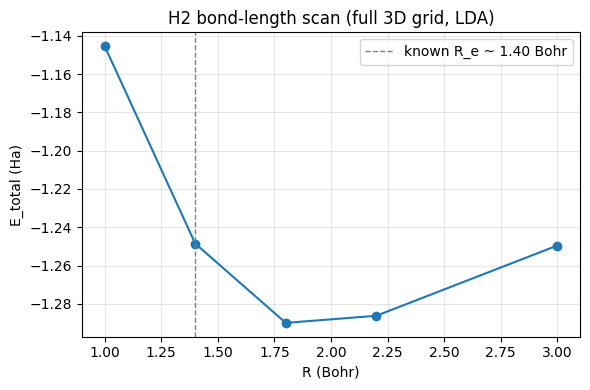

In [3]:
Rs_scan = [1.0, 1.4, 1.8, 2.2, 3.0]
E_scan = []
for R in Rs_scan:
    res = scf3d.run_scf(h2_nuclei(R), 2, grid, method='lda', n_states=3, max_iter=50)
    E_scan.append(res['E_total'])
    print(f'R={R:.2f}: E_total={res["E_total"]:.5f} Ha  N_check={res["N_check"]:.5f}')
E_scan = np.array(E_scan)

i_min = np.argmin(E_scan)
print(f'minimum in this scan: R={Rs_scan[i_min]:.2f} Bohr, E_total={E_scan[i_min]:.5f} Ha')
print('(known equilibrium: R_e ~ 1.40 Bohr)')

assert 0 < i_min < len(Rs_scan) - 1, 'the minimum should be interior to the scan, i.e. a genuine minimum was found'
print('PASS: a genuine bonding minimum falls out of the full 3D SCF, with no symmetry assumptions built in.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Rs_scan, E_scan, 'o-')
ax.axvline(1.4, color='gray', ls='--', lw=1, label='known R_e ~ 1.40 Bohr')
ax.set_xlabel('R (Bohr)'); ax.set_ylabel('E_total (Ha)')
ax.set_title('H2 bond-length scan (full 3D grid, LDA)')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/h2_3d_bond_curve.png', dpi=110)
plt.show()

A real bonding minimum falls out at the right bond length, purely from
the general 3D machinery -- kinetic and Poisson operators applied via
FFT, an iterative eigensolver, LDA exchange-correlation, no coordinate
system chosen to exploit the molecule's shape. This is the direct
successor to `HF_solver`'s atomic solver and `Diatomic_HF_solver`'s
two-center solver, and the natural foundation for adding pseudopotentials
and tackling real polyatomic molecules next (see `Molecular_DFT_Plan.md`'s
Scope decision -- explicitly future work, not attempted here).